In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [4]:
#data loading
df=pd.read_csv('/content/Iris.csv')

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
#identify all columns that starts with 'zero'
cols_to_remove=[col for col in df.columns if col.startswith('zero')]

#drop the columns
df_cleaned=df.drop(columns=cols_to_remove)
df_cleaned

# Display the new,clean head

df_cleaned.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Data Overview
Let's get a quick overview of the `df_cleaned` DataFrame, including data types, non-null values, and memory usage.

In [7]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
df.duplicated().sum()#finds the duplicated value
print(df.duplicated().sum())
#drop is the function to delete the duplicate the function if any duplicates are there
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0
0


In [9]:
#missing value treatment for object(mode)
df['Species']=df['Species'].fillna(df['Species'].mode()[0])
#missing value treatment for float(mean)
df['SepalLengthCm']=df['SepalLengthCm'].fillna(df['SepalLengthCm'].mean())
df['SepalWidthCm']=df['SepalWidthCm'].fillna(df['SepalWidthCm'].mean())
df['PetalLengthCm']=df['PetalLengthCm'].fillna(df['PetalLengthCm'].mean())
df['PetalWidthCm']=df['PetalWidthCm'].fillna(df['PetalWidthCm'].mean())

### Descriptive Statistics
Next, let's look at the descriptive statistics for the numerical columns in `df_cleaned`.

In [10]:
display(df_cleaned.describe())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


### Check for Missing Values
It's important to identify if there are any missing values in the dataset.

In [11]:
display(df_cleaned.isnull().sum())

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [12]:
df_cleaned.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

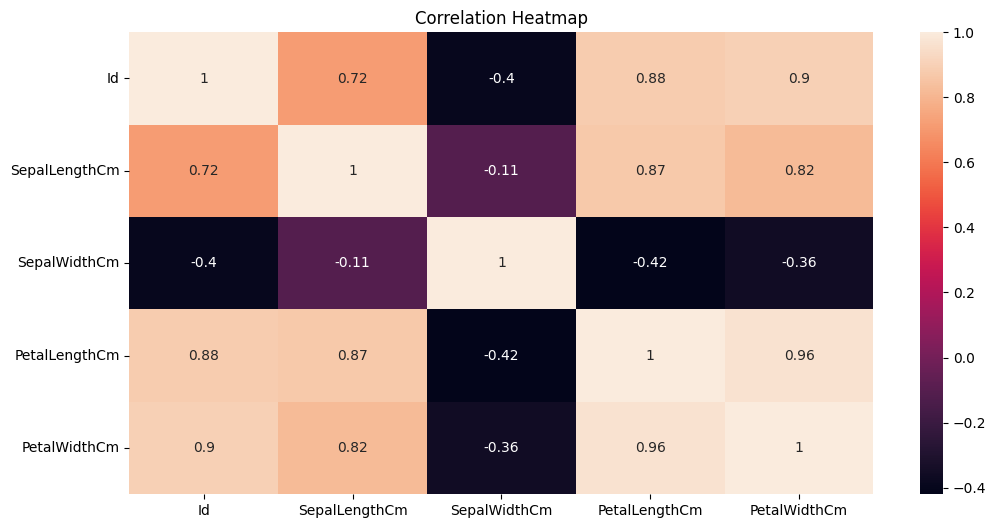

'1.0= is the perfect positive corrolation\n0= no linear positive corrolation'

In [13]:
#visualization
plt.figure(figsize=(12,6))
sns.heatmap(df_cleaned.drop('Species', axis=1).corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()
'''1.0= is the perfect positive corrolation
0= no linear positive corrolation'''
#Here the strongest relationship is b/w PetalLength and PetalWidth which is 0.96
#Here SepalWidth and PetalLength are negatively corrolated


In [14]:
features=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
#take independent variable in x value
#take dependent variable in y value
x=df_cleaned[features]
y=df_cleaned['Species']

### Encode the Target Variable
Since 'Species' is a categorical variable, we need to convert it into numerical labels before training a model.

In [15]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Original Species labels:", y.unique())
print("Encoded Species labels:", np.unique(y_encoded))

Original Species labels: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded Species labels: [0 1 2]


### Split Data into Training and Testing Sets
Now, we'll split the data into training and testing sets to evaluate our model's performance on unseen data. We'll use 80% for training and 20% for testing.

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [17]:
#initialize The Random forest
rf=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=None)

#train the model
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



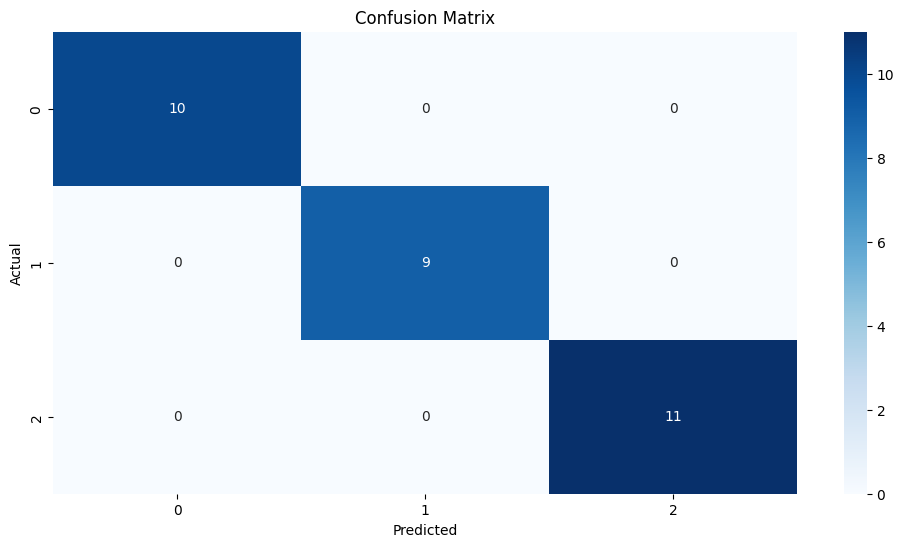

In [18]:
#checking how the model works on unseen data
y_pred=rf.predict(X_test)

#calculate accuracy
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

# Calculate and print precision, recall, and f1-score
report = classification_report(y_test, y_pred, target_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
print("\nClassification Report:\n", report)

#visualization
plt.figure(figsize=(12,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Here the Accuracy ,Precision ,Recall,F1 score all are 1.0 because the Predicted values are same as Actual Values.
This is a perfect classifier








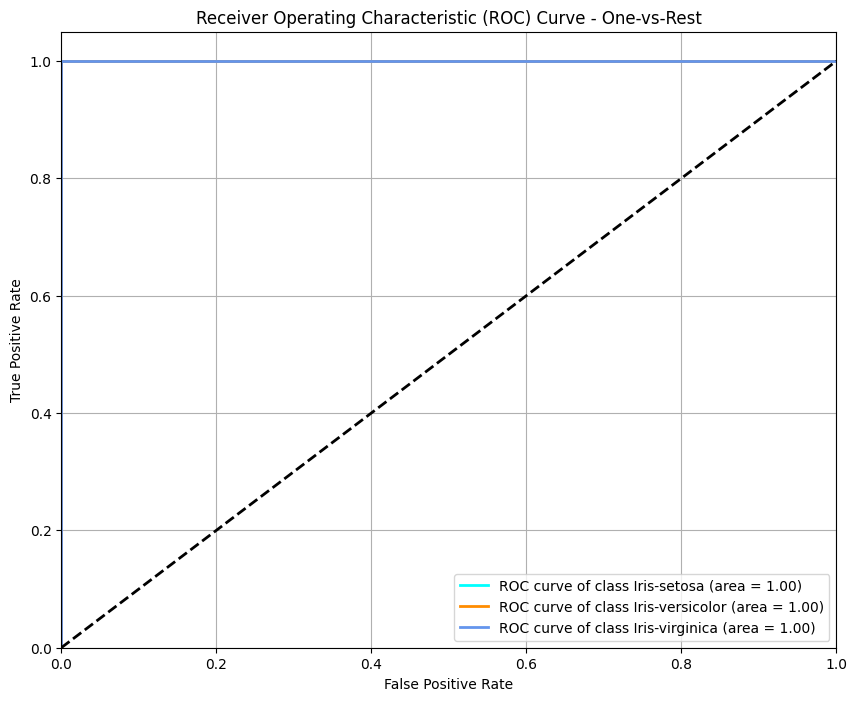

In [19]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get prediction probabilities for each class
y_pred_proba = rf.predict_proba(X_test)

# Binarize the true labels for one-vs-rest ROC calculation
n_classes = len(label_encoder.classes_)
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(label_encoder.classes_[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

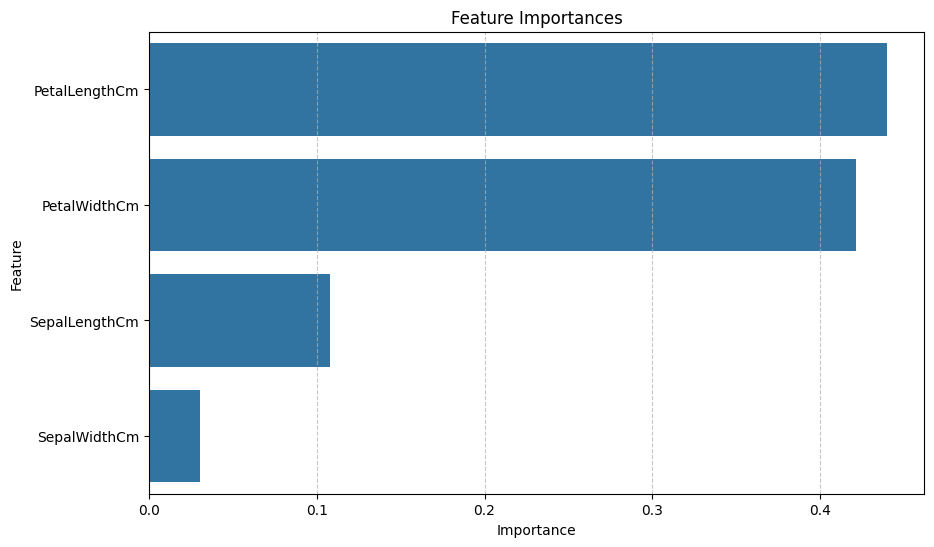

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
importances = rf.feature_importances_

# Get feature names from the DataFrame
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)#alpha shows transparency of line
plt.show()

The bar chart of feature importances visually confirms that for this Iris classification model, PetalLengthCm and PetalWidthCm are significantly more important for prediction than SepalLengthCm and SepalWidthCm.
